#1.데이터 불러오기

In [ ]:
import matplotlib
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt
import numpy as np
np.random.seed(16)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filename = '/content/drive/MyDrive/diabetes.csv'
df = pd.read_csv(filename)
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:
# 상위 5개 데이터를 출력한다
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#2.데이터 전처리

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

In [ ]:
df['Glucose'] = df['Glucose'].replace(0, np.nan)
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)
df['Insulin'] = df['Insulin'].replace(0, np.nan)
df['BMI'] = df['BMI'].replace(0, np.nan)

In [ ]:
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].mean())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].mean())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())

Outcome
0    500
1    268
Name: count, dtype: int64


/tmp/ipython-input-3631917653.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_df.index, y=count_df.values, palette='Set2')


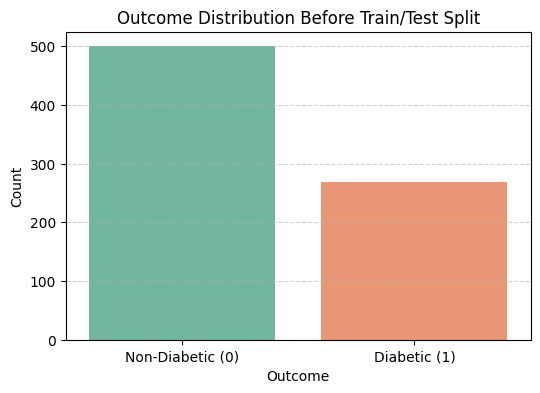

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 당뇨(1) / 비당뇨(0) 명수 집계
count_df = df['Outcome'].value_counts()

print(count_df)

# 시각화
plt.figure(figsize=(6,4))
sns.barplot(x=count_df.index, y=count_df.values, palette='Set2')

plt.xticks([0,1], ["Non-Diabetic (0)", "Diabetic (1)"])
plt.ylabel("Count")
plt.title("Outcome Distribution Before Train/Test Split")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


In [ ]:
# 데이터를 훈련 데이터셋과 테스트 데이터셋으로 분할

X = df.loc[:, df.columns != 'Outcome']
y = df.loc[:, 'Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 5)

🔹 Train 데이터 Outcome 분포
Outcome
0    400
1    214
Name: count, dtype: int64

🔹 Test 데이터 Outcome 분포
Outcome
0    100
1     54
Name: count, dtype: int64


/tmp/ipython-input-2079415840.py:30: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2079415840.py:30: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2079415840.py:30: UserWarning: Glyph 45544 (\N{HANGUL SYLLABLE NYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45544 (\N{HANGUL SYLLABLE NYO}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

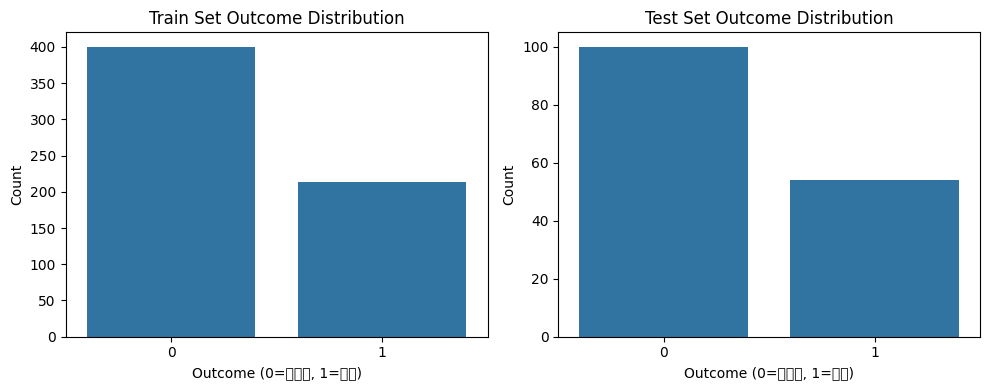

In [ ]:
# -------------------------------
# 1) Train/Test 클래스 분포 확인
# -------------------------------
print("🔹 Train 데이터 Outcome 분포")
print(y_train.value_counts())

print("\n🔹 Test 데이터 Outcome 분포")
print(y_test.value_counts())


# -------------------------------
# 2) Train/Test 분포 그래프 출력
# -------------------------------
plt.figure(figsize=(10,4))

# Train 그래프
plt.subplot(1,2,1)
sns.countplot(x=y_train)
plt.title("Train Set Outcome Distribution")
plt.xlabel("Outcome (0=비당뇨, 1=당뇨)")
plt.ylabel("Count")

# Test 그래프
plt.subplot(1,2,2)
sns.countplot(x=y_test)
plt.title("Test Set Outcome Distribution")
plt.xlabel("Outcome (0=비당뇨, 1=당뇨)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


In [ ]:
X_train.shape

(614, 8)

In [ ]:
print(X_train)

     Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
140            3    128.0           78.0       29.15342  155.548223  21.1   
358           12     88.0           74.0       40.00000   54.000000  35.3   
143           10    108.0           66.0       29.15342  155.548223  32.4   
674            8     91.0           82.0       29.15342  155.548223  35.6   
121            6    111.0           64.0       39.00000  155.548223  34.2   
..           ...      ...            ...            ...         ...   ...   
73             4    129.0           86.0       20.00000  270.000000  35.1   
400            4     95.0           64.0       29.15342  155.548223  32.0   
118            4     97.0           60.0       23.00000  155.548223  28.2   
701            6    125.0           78.0       31.00000  155.548223  27.6   
206            8    196.0           76.0       29.00000  280.000000  37.5   

     DiabetesPedigreeFunction  Age  
140                     0.268   55  
3

In [ ]:
print(y_train)

140    0
358    0
143    1
674    0
121    0
      ..
73     0
400    1
118    0
701    1
206    1
Name: Outcome, Length: 614, dtype: int64


In [ ]:
# 1) scaler는 train만 보고 학습
scaler = StandardScaler()
scaler.fit(X_train)

# 2) 학습된 scaler로 train/test 각각 변환
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

#3.모델 생성

##3.1 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# 로지스틱 회귀 모델 생성
log_clf = LogisticRegression(max_iter=1000)   # 반복 횟수 늘려줌(중요!)

# 모델 학습
log_clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = log_clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8116883116883117


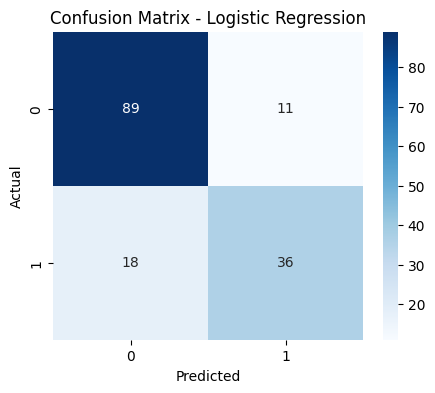

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

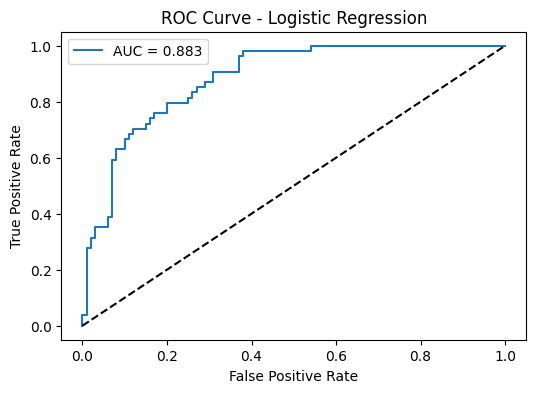

In [ ]:
from sklearn.metrics import roc_curve, auc

# Positive class 확률 가져오기
y_prob = log_clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.89      0.86       100
           1       0.77      0.67      0.71        54

    accuracy                           0.81       154
   macro avg       0.80      0.78      0.79       154
weighted avg       0.81      0.81      0.81       154




🔹 Logistic Regression Feature Importances:
                    Feature  Coefficient  Importance(Abs)
1                   Glucose     1.041351         1.041351
5                       BMI     0.580576         0.580576
0               Pregnancies     0.407253         0.407253
6  DiabetesPedigreeFunction     0.304266         0.304266
7                       Age     0.179539         0.179539
2             BloodPressure    -0.134027         0.134027
3             SkinThickness     0.060811         0.060811
4                   Insulin    -0.026574         0.026574


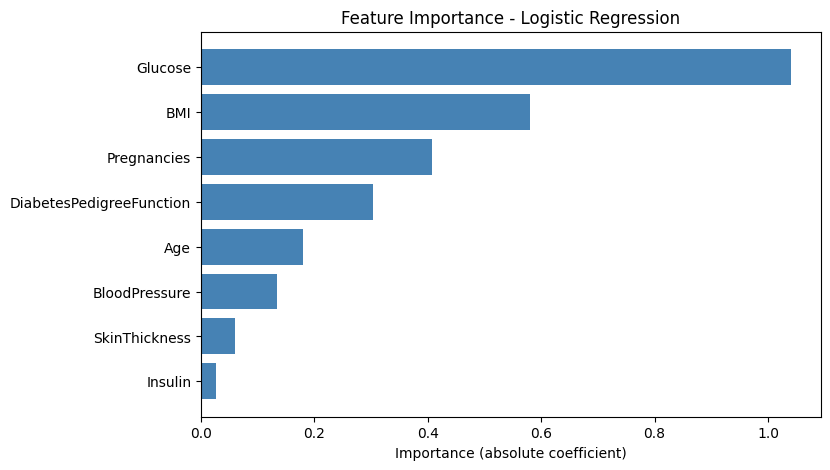

In [ ]:
# ==============================
# 🔥 Logistic Regression 변수 중요도
# ==============================
import pandas as pd
import numpy as np

# 로지스틱 회귀 계수는 shape이 (1, n_features)
coefficients = log_clf.coef_[0]

# 변수명 가져오기
feature_names = X.columns

# DataFrame으로 정리
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance(Abs)': np.abs(coefficients)
})

# 중요도 기준 정렬
importance_df = importance_df.sort_values(by='Importance(Abs)', ascending=False)

print("\n🔹 Logistic Regression Feature Importances:")
print(importance_df)

# 시각화 (선택)
plt.figure(figsize=(8,5))
plt.barh(importance_df['Feature'], importance_df['Importance(Abs)'], color='steelblue')
plt.xlabel("Importance (absolute coefficient)")
plt.title("Feature Importance - Logistic Regression")
plt.gca().invert_yaxis()
plt.show()


##3.2 Polynomial Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# PolynomialFeatures + Logistic Regression 파이프라인 구성
poly_log_reg = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('log_reg', LogisticRegression(max_iter=10000))
])

# 모델 학습
poly_log_reg.fit(X_train, y_train)

# 예측
y_pred = poly_log_reg.predict(X_test)

# 정확도 출력
print("🔹 Accuracy:", accuracy_score(y_test, y_pred))

# 분류 리포트
print("\n🔹 Classification Report:")
print(classification_report(y_test, y_pred))

# 혼동행렬
print("\n🔹 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


🔹 Accuracy: 0.7987012987012987

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       100
           1       0.73      0.69      0.70        54

    accuracy                           0.80       154
   macro avg       0.78      0.77      0.78       154
weighted avg       0.80      0.80      0.80       154


🔹 Confusion Matrix:
[[86 14]
 [17 37]]



🔹 AUC Score: 0.8888888888888888


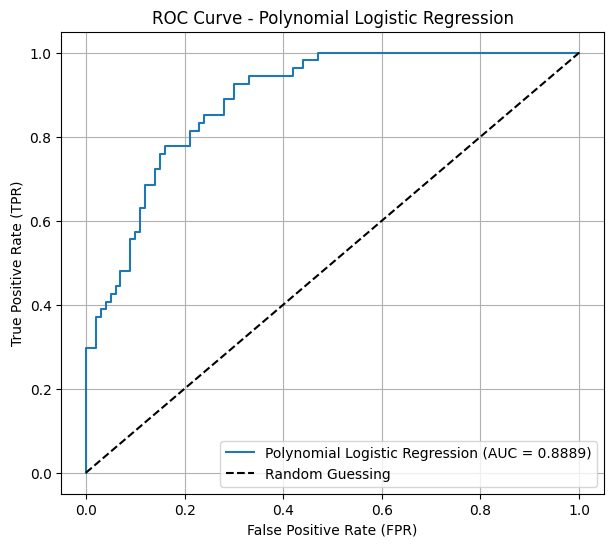

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# ---------- ROC 커브 & AUC 계산 ----------
# 예측 확률 가져오기 (양성 클래스 = 1 확률)
y_pred_proba = poly_log_reg.predict_proba(X_test)[:, 1]

# FPR, TPR 계산
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# AUC 계산
auc_score = roc_auc_score(y_test, y_pred_proba)

print("\n🔹 AUC Score:", auc_score)

# ---------- ROC Curve 그리기 ----------
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Polynomial Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - Polynomial Logistic Regression')
plt.legend()
plt.grid()

plt.show()


In [ ]:
# ================================================
# ★ Polynomial Logistic Regression Feature Importance ★
# ================================================
import numpy as np
import pandas as pd

# 파이프라인 내부 단계 꺼내기
poly = poly_log_reg.named_steps['poly']
log_reg = poly_log_reg.named_steps['log_reg']

# 1) PolynomialFeatures로 확장된 특성 이름 가져오기
poly_feature_names = poly.get_feature_names_out(X.columns)

# 2) Logistic Regression 계수 가져오기
coefficients = log_reg.coef_[0]   # 이진 분류 → 1개의 coef 벡터

# 3) 표 형태로 정리
importance_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': coefficients,
    'AbsCoefficient': np.abs(coefficients)   # 중요도 비교 위해 절대값 추가
})

# 4) 중요도 순으로 정렬
importance_df = importance_df.sort_values(by='AbsCoefficient', ascending=False)

# 출력
print("\n🔹 Polynomial Logistic Regression Feature Importance (sorted):")
print(importance_df)



🔹 Polynomial Logistic Regression Feature Importance (sorted):
                                   Feature  Coefficient  AbsCoefficient
1                                  Glucose     1.237381        1.237381
7                                      Age     0.656903        0.656903
5                                      BMI     0.599981        0.599981
6                 DiabetesPedigreeFunction     0.476363        0.476363
37                             Insulin Age     0.461713        0.461713
43                                   Age^2    -0.422202        0.422202
28                       BloodPressure Age     0.338223        0.338223
0                              Pregnancies     0.279488        0.279488
15                         Pregnancies Age    -0.265112        0.265112
39            BMI DiabetesPedigreeFunction    -0.227468        0.227468
14    Pregnancies DiabetesPedigreeFunction     0.224493        0.224493
31                       SkinThickness BMI    -0.218478        0.218478
4

##3.3 SVM

🔹 Linear SVM Accuracy: 0.8246753246753247

🔹 Linear SVM Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       100
           1       0.80      0.67      0.73        54

    accuracy                           0.82       154
   macro avg       0.82      0.79      0.80       154
weighted avg       0.82      0.82      0.82       154


🔹 Linear SVM Confusion Matrix:
[[91  9]
 [18 36]]


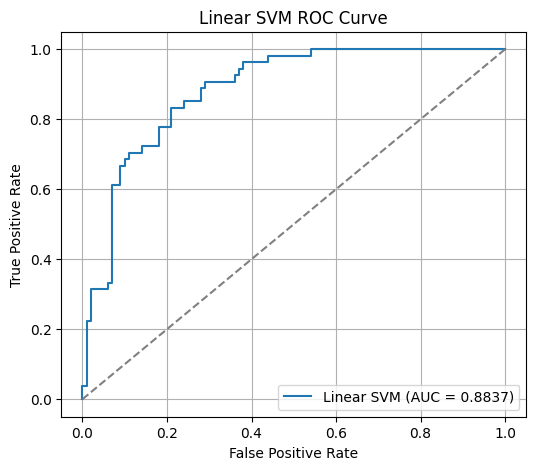

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) 선형 SVM 모델 생성
# --------------------------------------------------
linear_svm = SVC(kernel='linear', probability=True, random_state=5)

# --------------------------------------------------
# 2) 모델 학습
# --------------------------------------------------
linear_svm.fit(X_train, y_train)

# --------------------------------------------------
# 3) 예측
# --------------------------------------------------
y_pred_linear = linear_svm.predict(X_test)

# --------------------------------------------------
# 4) 성능 출력
# --------------------------------------------------
print("🔹 Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))

print("\n🔹 Linear SVM Classification Report:")
print(classification_report(y_test, y_pred_linear))

print("\n🔹 Linear SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear))

# --------------------------------------------------
# 5) ROC Curve + AUC
# --------------------------------------------------
y_prob_linear = linear_svm.predict_proba(X_test)[:, 1]  # Positive 클래스 확률

fpr, tpr, thresholds = roc_curve(y_test, y_prob_linear)
linear_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Linear SVM (AUC = {linear_auc:.4f})")
plt.plot([0, 1], [0, 1], '--', color='gray')

plt.title("Linear SVM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# --------------------------------------------------
# 6) Feature Importance (선형 SVM만 가능!)
# --------------------------------------------------

import pandas as pd
import numpy as np

# SVM 계수(가중치)
coefficients = linear_svm.coef_[0]   # (1, n_features) → 1차원으로 사용

# 변수 이름
feature_names = X.columns

# 데이터프레임으로 정리
svm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefficients)    # 절대값(영향력 크기)을 중요도로 사용
})

# 중요도 내림차순 정렬
svm_importance_df = svm_importance_df.sort_values(by='Importance', ascending=False)

print("\n🔹 Feature Importance (Linear SVM):")
print(svm_importance_df)



🔹 Feature Importance (Linear SVM):
                    Feature  Importance
1                   Glucose    0.824814
5                       BMI    0.446928
0               Pregnancies    0.358289
6  DiabetesPedigreeFunction    0.226687
2             BloodPressure    0.092281
7                       Age    0.061730
4                   Insulin    0.017646
3             SkinThickness    0.005078


##3.4 SVM(rbf커널 사용)

🔹 SVM Accuracy: 0.7792207792207793

🔹 SVM Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154


🔹 SVM Confusion Matrix:
[[88 12]
 [22 32]]


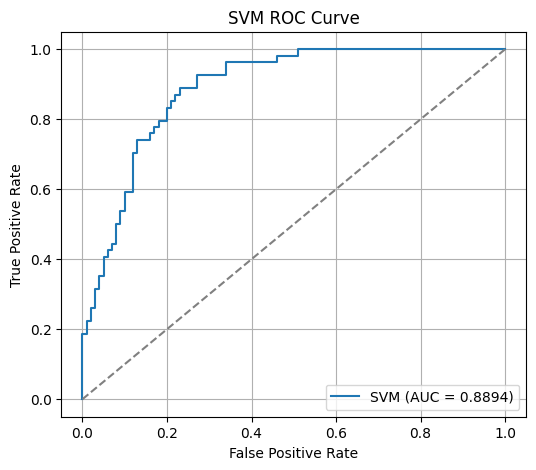

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) SVM 모델 생성 (probability=True → ROC 커브 위해 필요)
# --------------------------------------------------
svm_clf = SVC(kernel='rbf', probability=True, random_state=5)

# --------------------------------------------------
# 2) 모델 학습
# --------------------------------------------------
svm_clf.fit(X_train, y_train)

# --------------------------------------------------
# 3) 예측
# --------------------------------------------------
y_pred_svm = svm_clf.predict(X_test)

# --------------------------------------------------
# 4) 성능 출력
# --------------------------------------------------
print("🔹 SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\n🔹 SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

print("\n🔹 SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

# --------------------------------------------------
# 5) ROC Curve + AUC
# --------------------------------------------------
y_prob_svm = svm_clf.predict_proba(X_test)[:, 1]  # 1일 확률

fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)
svm_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"SVM (AUC = {svm_auc:.4f})")
plt.plot([0, 1], [0, 1], '--', color='gray')

plt.title("SVM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


##3.5 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_DT.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

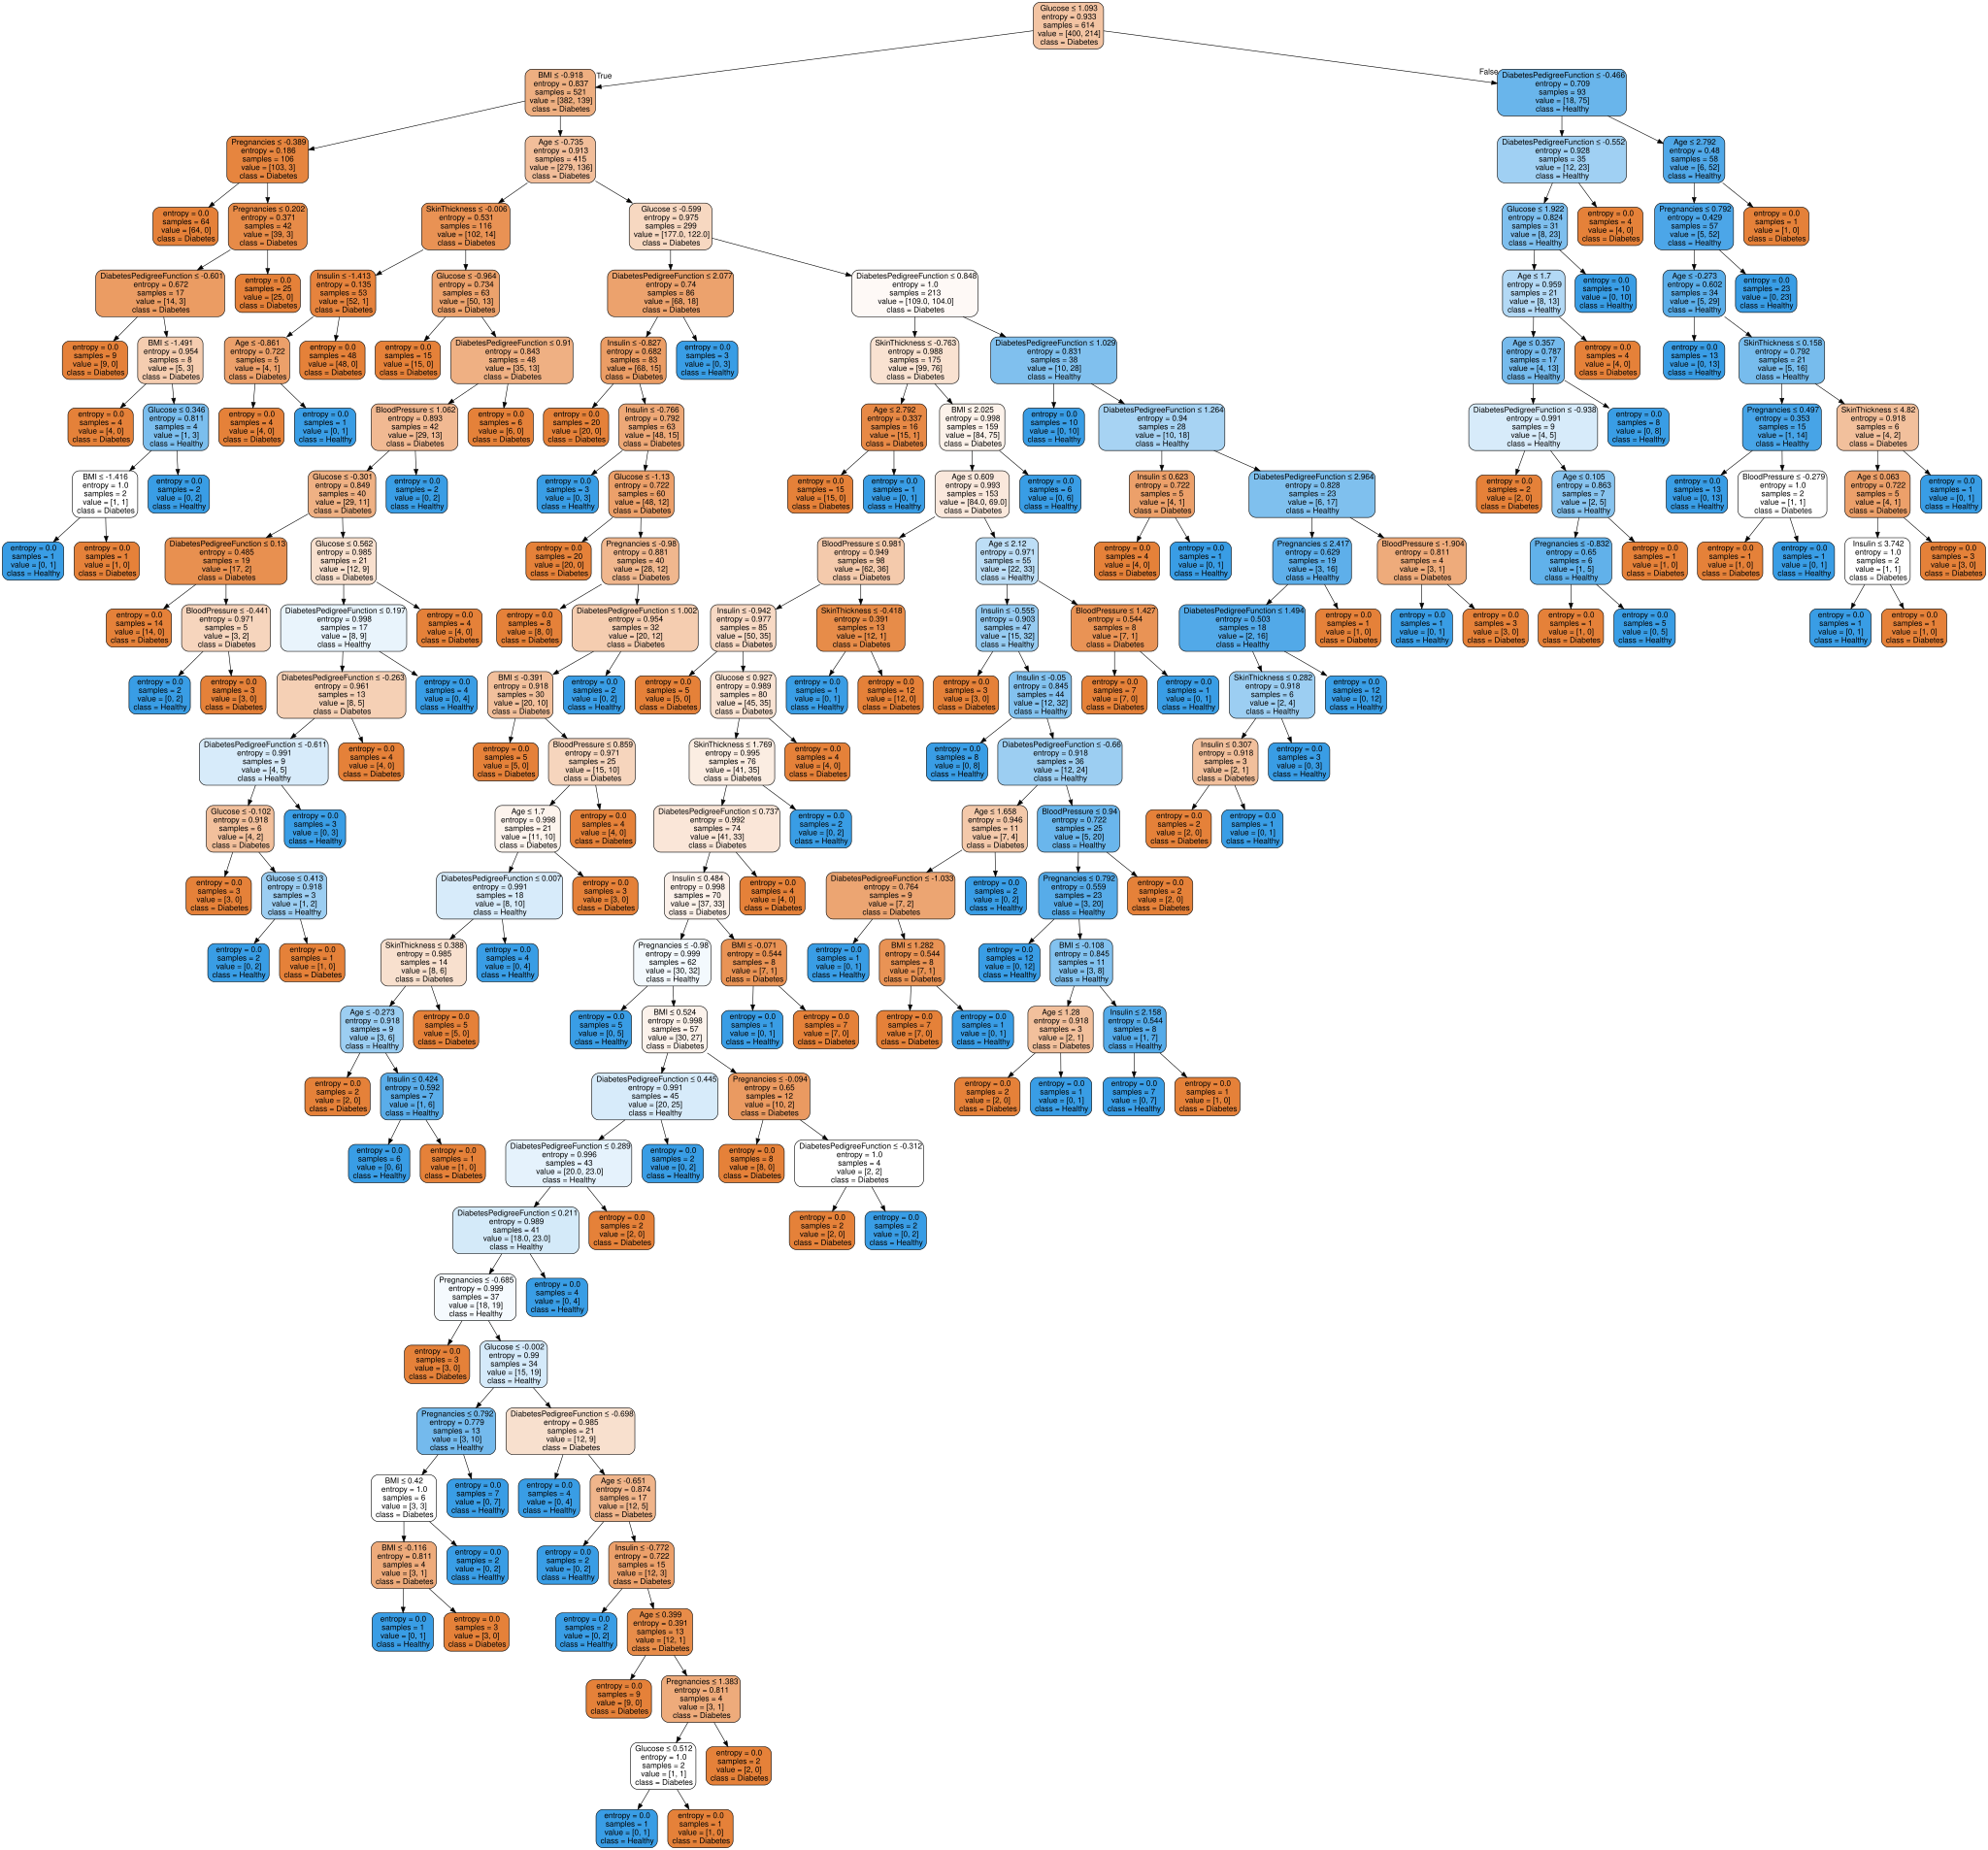

In [ ]:
from sklearn import tree

import graphviz
from PIL import Image
dot_data = tree.export_graphviz(model_DT, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("Titanic")

dot_data = tree.export_graphviz(model_DT, out_file=None,
                         feature_names=X.columns.values,
                         class_names=['Diabetes','Healthy'],
                         filled=True, rounded=True,
                         special_characters=True)

graph = graphviz.Source(dot_data)       # 새 graph 객체 생성
graph.render("Titanic", format="png")   # 파일 저장
graph                                    # Colab/Notebook에서 출력

In [ ]:
y_pred = model_DT.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1])

In [ ]:
from sklearn import metrics

print('DecisionTreeClassifier: %.2f' % (metrics.accuracy_score(y_test, y_pred) * 100))

DecisionTreeClassifier: 77.92


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[82 18]
 [16 38]]


In [ ]:
from sklearn.metrics import classification_report

# 리포트 생성
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83       100
           1       0.68      0.70      0.69        54

    accuracy                           0.78       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.78      0.78       154



In [ ]:
#변수 중요도
feature_importances = model_DT.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("All Feature Importances from RandomForestClassifier (sorted):")
print(importance_df)

All Feature Importances from RandomForestClassifier (sorted):
                    Feature  Importance
1                   Glucose    0.223459
6  DiabetesPedigreeFunction    0.183481
7                       Age    0.153995
5                       BMI    0.131507
4                   Insulin    0.098353
0               Pregnancies    0.084070
3             SkinThickness    0.070479
2             BloodPressure    0.054656


##3.6 Random Forest

🔹 Random Forest Accuracy: 0.7987012987012987

🔹 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       100
           1       0.73      0.69      0.70        54

    accuracy                           0.80       154
   macro avg       0.78      0.77      0.78       154
weighted avg       0.80      0.80      0.80       154


🔹 Random Forest Confusion Matrix:
[[86 14]
 [17 37]]


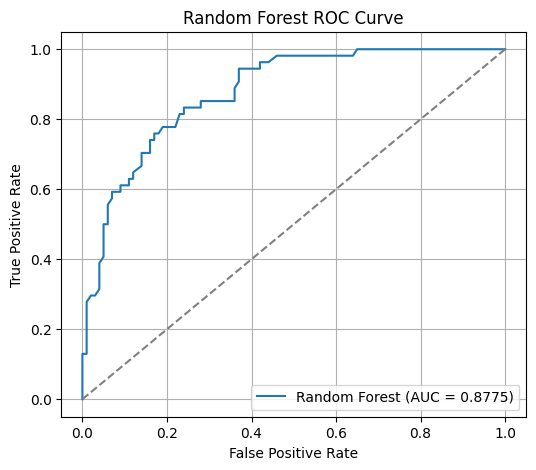

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) Random Forest 모델 생성
# --------------------------------------------------
rf_clf = RandomForestClassifier(
    n_estimators=200,     # 트리 개수
    max_depth=None,       # 깊이 제한 없음
    random_state=5
)

# --------------------------------------------------
# 2) 모델 학습
# --------------------------------------------------
rf_clf.fit(X_train, y_train)

# --------------------------------------------------
# 3) 예측
# --------------------------------------------------
y_pred_rf = rf_clf.predict(X_test)

# --------------------------------------------------
# 4) 성능 출력
# --------------------------------------------------
print("🔹 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\n🔹 Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n🔹 Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# --------------------------------------------------
# 5) ROC Curve + AUC
# --------------------------------------------------
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
rf_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {rf_auc:.4f})")
plt.plot([0, 1], [0, 1], '--', color='gray')

plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()



🔹 Random Forest Feature Importances:
                    Feature  Importance
1                   Glucose    0.251098
5                       BMI    0.148957
7                       Age    0.139911
6  DiabetesPedigreeFunction    0.122752
0               Pregnancies    0.086631
4                   Insulin    0.084687
2             BloodPressure    0.084524
3             SkinThickness    0.081441


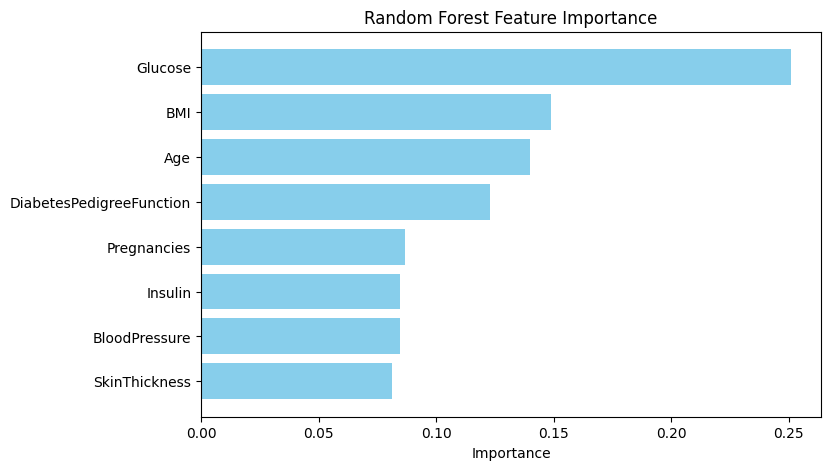

In [ ]:
# --------------------------------------------------
# 6) 변수 중요도 (Feature Importance)
# --------------------------------------------------
import pandas as pd
import numpy as np

# 변수 중요도 추출
importances = rf_clf.feature_importances_
feature_names = X.columns

# 데이터프레임 생성
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 중요도 순 정렬
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n🔹 Random Forest Feature Importances:")
print(importance_df)

# 시각화
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()   # 가장 중요한 변수를 위로
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()


##3.7 XGBoost

🔹 XGBoost Accuracy: 0.8051948051948052

🔹 XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       100
           1       0.73      0.70      0.72        54

    accuracy                           0.81       154
   macro avg       0.79      0.78      0.78       154
weighted avg       0.80      0.81      0.80       154


🔹 XGBoost Confusion Matrix:
[[86 14]
 [16 38]]


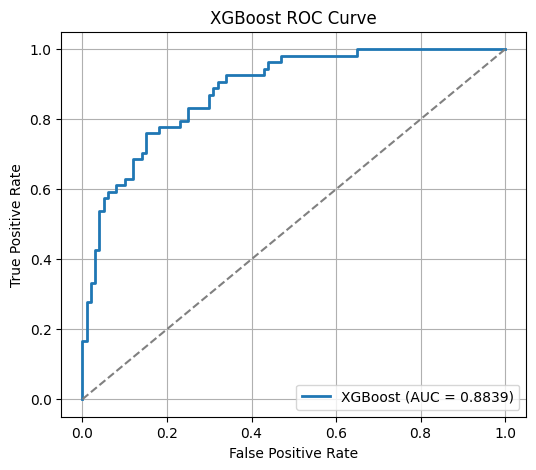

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) XGBoost 모델 생성
# --------------------------------------------------
xgb_clf = XGBClassifier(
    n_estimators=300,       # 트리 개수
    learning_rate=0.05,    # 학습률
    max_depth=4,           # 트리 깊이
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=5,
    eval_metric='logloss'  # 이진 분류 일반적인 설정
)

# --------------------------------------------------
# 2) 모델 학습
# --------------------------------------------------
xgb_clf.fit(X_train, y_train)

# --------------------------------------------------
# 3) 예측
# --------------------------------------------------
y_pred_xgb = xgb_clf.predict(X_test)

# --------------------------------------------------
# 4) 정확도 및 리포트 출력
# --------------------------------------------------
print("🔹 XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\n🔹 XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\n🔹 XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

# --------------------------------------------------
# 5) ROC Curve + AUC
# --------------------------------------------------
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
xgb_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {xgb_auc:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], '--', color='gray')

plt.title("XGBoost ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()



🔹 XGBoost Feature Importances (sorted):
                    Feature  Importance
1                   Glucose    0.217970
5                       BMI    0.140000
7                       Age    0.138835
4                   Insulin    0.108778
3             SkinThickness    0.107131
0               Pregnancies    0.104856
6  DiabetesPedigreeFunction    0.099244
2             BloodPressure    0.083186


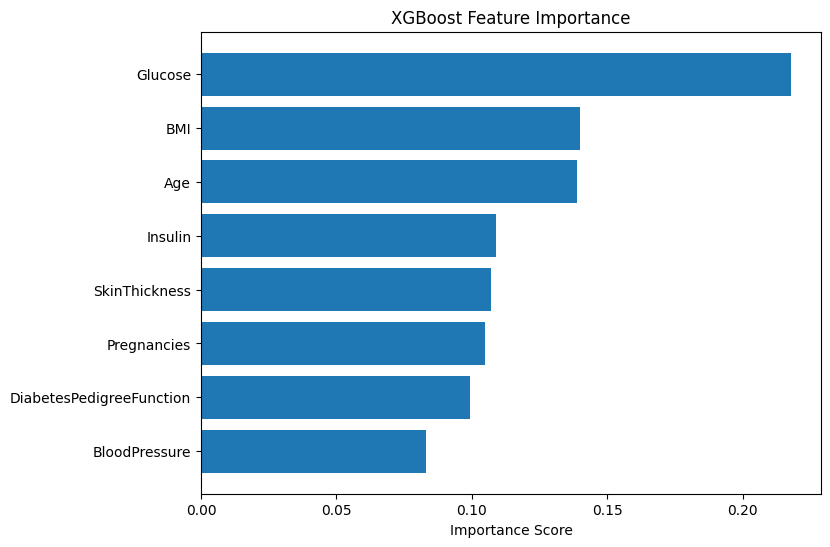

In [ ]:
# --------------------------------------------------
# 6) Feature Importance (변수 중요도)
# --------------------------------------------------
import pandas as pd
import numpy as np

# 변수 중요도 가져오기
importance_values = xgb_clf.feature_importances_
feature_names = X.columns

# 데이터프레임으로 정리
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# 중요도 순으로 정렬
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n🔹 XGBoost Feature Importances (sorted):")
print(importance_df)

# 시각화 (막대그래프)
plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()   # 중요도가 높은 것이 위로 오도록
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.show()


##3.8  딥러닝

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

# Define the model
model_DL = Sequential([
    Input(shape=(X_train.shape[1],)),  # Input layer with number of features
    Dense(64, activation='relu'),      # Hidden layer 1                     # Dropout for regularization
    Dense(32, activation='relu'),      # Hidden layer 2                   # Dropout for regularization
    Dense(1, activation='sigmoid')     # Output layer for binary classification
])

# Compile the model
model_DL.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model_DL.fit(
    X_train,
    y_train,
    epochs=50,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_split=0.2, # Use a portion of training data for validation
    verbose=1
)

# Evaluate the model
loss, accuracy = model_DL.evaluate(X_test, y_test, verbose=0)
print(f"Deep Learning Model Test Accuracy: {accuracy:.4f}")

# Make predictions
y_pred_dl = (model_DL.predict(X_test) > 0.5).astype("int32")

# Print classification report
from sklearn.metrics import classification_report
print("\nDeep Learning Model Classification Report:")
print(classification_report(y_test, y_pred_dl))

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7177 - loss: 0.6152 - val_accuracy: 0.7073 - val_loss: 0.5574
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7487 - loss: 0.5334 - val_accuracy: 0.7236 - val_loss: 0.5069
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7708 - loss: 0.4857 - val_accuracy: 0.7317 - val_loss: 0.4813
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7632 - loss: 0.4873 - val_accuracy: 0.6992 - val_loss: 0.4665
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7966 - loss: 0.4581 - val_accuracy: 0.7317 - val_loss: 0.4790
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7852 - loss: 0.4548 - val_accuracy: 0.7236 - val_loss: 0.4826
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7901 - loss: 0.4479 - val_accuracy: 0.7154 - val_loss: 0.4793
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7819 - loss: 0.4487 - val_accuracy: 0.7154 - val_loss

In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dl))

Confusion Matrix:
[[88 12]
 [18 36]]


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


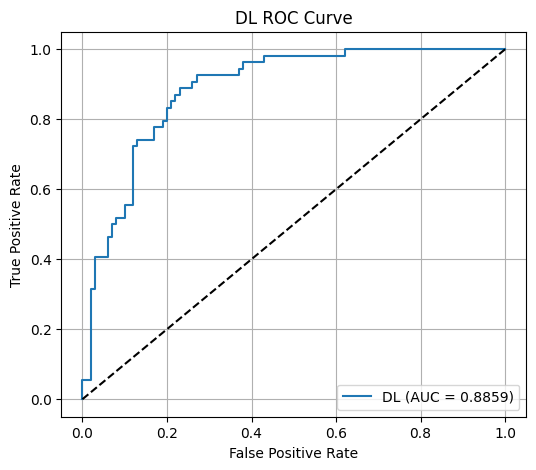

In [ ]:
# -------------------------
# 5) ROC & AUC
# -------------------------
y_prob_mlp = model_DL.predict(X_test).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_prob_mlp)
dl_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"DL (AUC = {dl_auc:.4f})")
plt.plot([0,1], [0,1], 'k--')
plt.title("DL ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


#4.최적의 모델 찾기

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


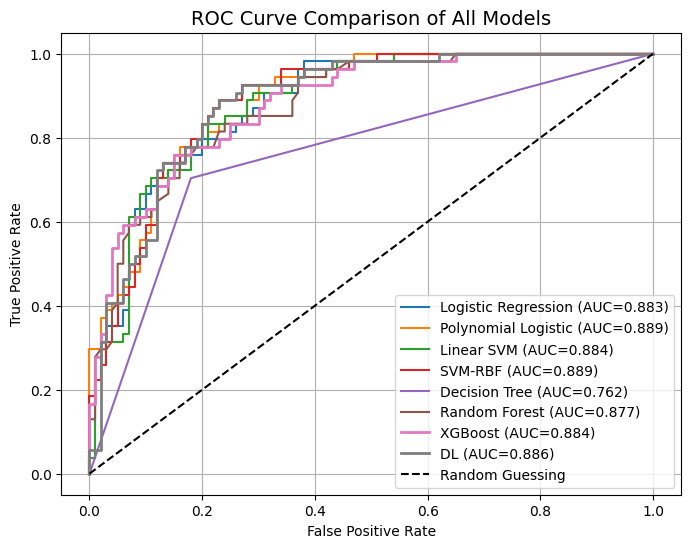


=== AUC Scores for All Models ===
Logistic Regression: 0.8831
Polynomial Logistic: 0.8889
Linear SVM: 0.8837
SVM-RBF: 0.8894
Decision Tree: 0.7619
Random Forest: 0.8775
XGBoost: 0.8839
DL: 0.8859


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

# ------------------------------------------------------------
# 1) Logistic Regression
# ------------------------------------------------------------
y_prob_log = log_clf.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={auc_log:.3f})")

# ------------------------------------------------------------
# 2) Polynomial Logistic Regression
# ------------------------------------------------------------
y_prob_poly = poly_log_reg.predict_proba(X_test)[:, 1]
fpr_poly, tpr_poly, _ = roc_curve(y_test, y_prob_poly)
auc_poly = auc(fpr_poly, tpr_poly)
plt.plot(fpr_poly, tpr_poly, label=f"Polynomial Logistic (AUC={auc_poly:.3f})")

# ------------------------------------------------------------
# 3) Linear SVM
# ------------------------------------------------------------
y_prob_linear = linear_svm.predict_proba(X_test)[:, 1]
fpr_linear, tpr_linear, _ = roc_curve(y_test, y_prob_linear)
auc_linear = auc(fpr_linear, tpr_linear)
plt.plot(fpr_linear, tpr_linear, label=f"Linear SVM (AUC={auc_linear:.3f})")

# ------------------------------------------------------------
# 4) RBF SVM
# ------------------------------------------------------------
y_prob_rbf = svm_clf.predict_proba(X_test)[:, 1]
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_prob_rbf)
auc_rbf = auc(fpr_rbf, tpr_rbf)
plt.plot(fpr_rbf, tpr_rbf, label=f"SVM-RBF (AUC={auc_rbf:.3f})")

# ------------------------------------------------------------
# 5) Decision Tree
# ------------------------------------------------------------
y_prob_dt = model_DT.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={auc_dt:.3f})")

# ------------------------------------------------------------
# 6) Random Forest
# ------------------------------------------------------------
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")

# ------------------------------------------------------------
# 7) XGBoost
# ------------------------------------------------------------
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})", linewidth=2)

# ------------------------------------------------------------
# 8) DL
# ------------------------------------------------------------
# DL 예측 확률
y_prob_dl = model_DL.predict(X_test).ravel()  # (N,1) → (N,)

# ROC Curve
fpr_dl, tpr_dl, _ = roc_curve(y_test, y_prob_dl)
auc_dl = auc(fpr_dl, tpr_dl)

# Plot
plt.plot(fpr_dl, tpr_dl, label=f"DL (AUC={auc_dl:.3f})", linewidth=2)


# ------------------------------------------------------------
# 그래프 꾸미기
# ------------------------------------------------------------
plt.plot([0,1], [0,1], 'k--', label="Random Guessing")

plt.title("ROC Curve Comparison of All Models", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# AUC 점수 테이블 출력
# ------------------------------------------------------------
print("\n=== AUC Scores for All Models ===")
print(f"Logistic Regression: {auc_log:.4f}")
print(f"Polynomial Logistic: {auc_poly:.4f}")
print(f"Linear SVM: {auc_linear:.4f}")
print(f"SVM-RBF: {auc_rbf:.4f}")
print(f"Decision Tree: {auc_dt:.4f}")
print(f"Random Forest: {auc_rf:.4f}")
print(f"XGBoost: {auc_xgb:.4f}")
print(f"DL: {auc_dl:.4f}")


SVM-RBF: 0.8894로 가장 좋은 모델, 정확도는 Linear SVM: 0.8246753246753247 으로 가장 높음